REAL INSTAGRAM IMAGE - DEEP FEATURE ANALYSIS

Project root:
d:\newwwwwwww\AiBasedInstagramPrediction

Feature directory:
d:\newwwwwwww\AiBasedInstagramPrediction\datasets\processed\real_image_features

FILE VALIDATION
Feature file : FOUND
Metadata file: FOUND

FEATURE FILE:
d:\newwwwwwww\AiBasedInstagramPrediction\datasets\processed\real_image_features\real_resnet50_features.npy

METADATA FILE:
d:\newwwwwwww\AiBasedInstagramPrediction\datasets\processed\real_image_features\real_resnet50_metadata.csv

LOADING RESNET-50 FEATURES

Feature matrix shape:
(34926, 2048)

Metadata shape:
(34926, 6)

Metadata columns:
['record_id', 'image_file', 'caption', 'dataset_source', 'image_path', 'feature_row']

FEATURE-METADATA CONSISTENCY
Feature rows : 34926
Metadata rows: 34926

ROW COUNT CHECK: PASSED

Deep visual feature dimension: 2048
ResNet-50 feature dimension check: PASSED

FEATURE QUALITY AUDIT
NaN values     : 0
Infinite values: 0

FEATURE NUMERICAL QUALITY: PASSED

FEATURE STATISTICS
   fe

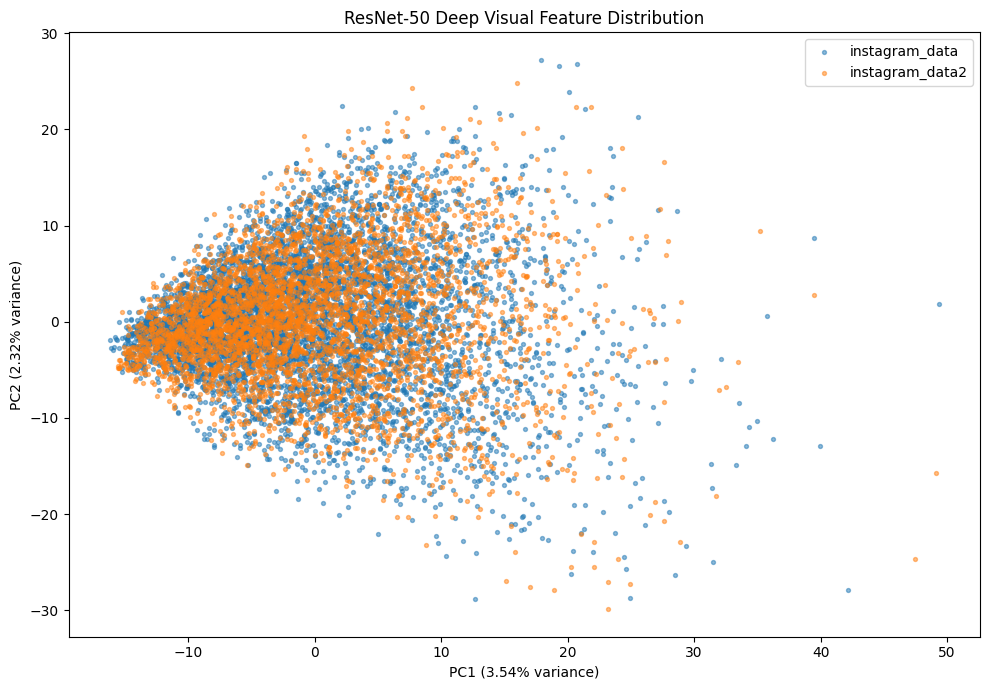


PCA plot saved: d:\newwwwwwww\AiBasedInstagramPrediction\results\real_image_analysis\resnet50_pca_2d.png

PCA EXPLAINED VARIANCE ANALYSIS
 5 components: 11.1707% cumulative variance
10 components: 16.4325% cumulative variance
20 components: 23.0326% cumulative variance
30 components: 27.4341% cumulative variance
40 components: 30.8646% cumulative variance
50 components: 33.6373% cumulative variance


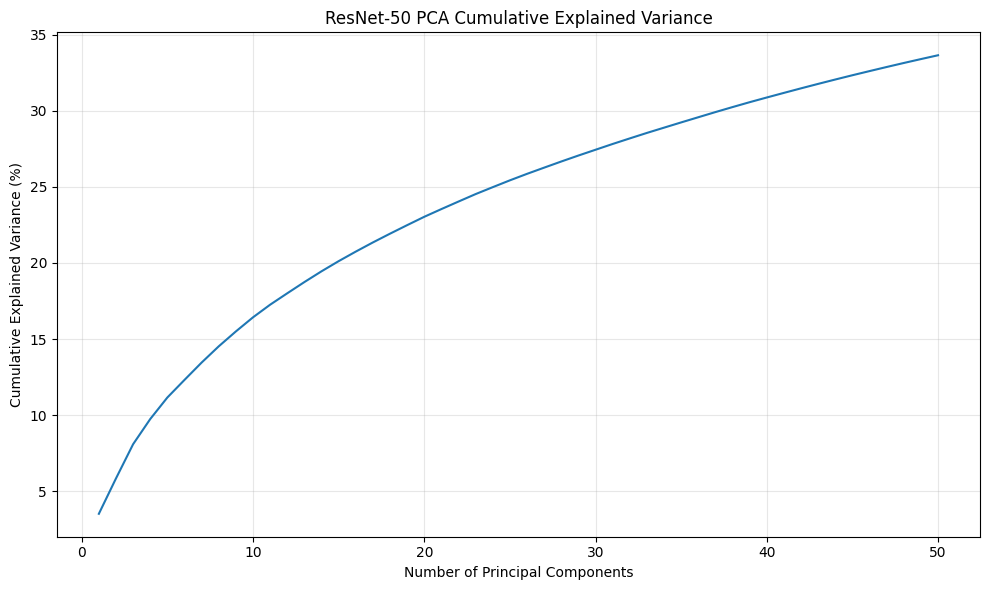


PCA variance plot saved: d:\newwwwwwww\AiBasedInstagramPrediction\results\real_image_analysis\resnet50_pca_cumulative_variance.png

VISUAL FEATURE CLUSTERING

Testing K=3...
Silhouette score: 0.0841

Testing K=4...
Silhouette score: -0.0132

Testing K=5...
Silhouette score: 0.0331

Testing K=6...
Silhouette score: 0.0788

Cluster evaluation:
   k  silhouette_score
0  3          0.084106
1  4         -0.013200
2  5          0.033054
3  6          0.078816

Best exploratory cluster count: 3


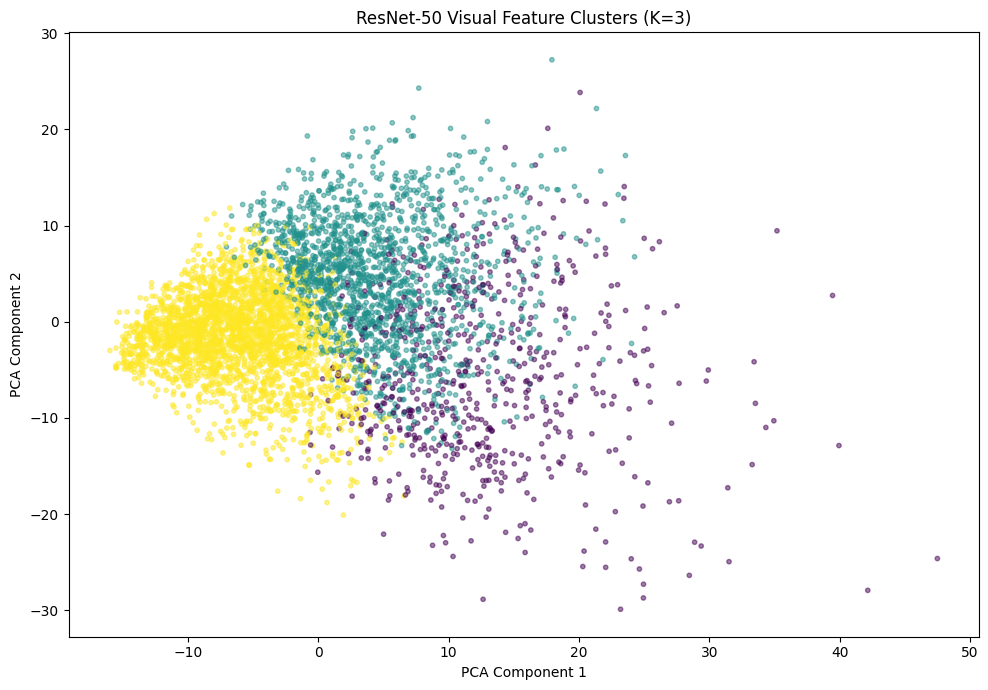


Cluster plot saved: d:\newwwwwwww\AiBasedInstagramPrediction\results\real_image_analysis\resnet50_visual_clusters.png

REAL IMAGE FEATURE ANALYSIS COMPLETED

Real images analysed: 34926
Deep visual features: 2048
NaN values: 0
Infinite values: 0
PCA 2D variance: 5.8584%
PCA 50 cumulative variance: 33.6373%
Best exploratory K: 3
Best silhouette score: 0.0841

Results directory:
d:\newwwwwwww\AiBasedInstagramPrediction\results\real_image_analysis

Generated outputs:
- resnet50_feature_statistics.csv
- resnet50_feature_variance.csv
- real_dataset_source_distribution.csv
- real_caption_statistics.csv
- resnet50_pca_2d.png
- resnet50_pca_cumulative_variance.png
- resnet50_cluster_analysis.csv
- resnet50_visual_clusters.png
- real_resnet50_pca_coordinates.csv
- real_image_feature_analysis_summary.json

READY FOR REAL-DATA MULTIMODAL INTEGRATION


In [1]:
# ================================================================
# REAL INSTAGRAM IMAGE - DEEP FEATURE ANALYSIS
# AI-Based Instagram Engagement Prediction and Content Optimization System
# ================================================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")


# ================================================================
# 1. PROJECT CONFIGURATION
# ================================================================

PROJECT_ROOT = Path(
    r"d:\newwwwwwww\AiBasedInstagramPrediction"
)

FEATURE_DIR = (
    PROJECT_ROOT
    / "datasets"
    / "processed"
    / "real_image_features"
)

FEATURE_FILE = (
    FEATURE_DIR
    / "real_resnet50_features.npy"
)

METADATA_FILE = (
    FEATURE_DIR
    / "real_resnet50_metadata.csv"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "real_image_analysis"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 70)
print("REAL INSTAGRAM IMAGE - DEEP FEATURE ANALYSIS")
print("=" * 70)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nFeature directory:")
print(FEATURE_DIR)


# ================================================================
# 2. FILE VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("FILE VALIDATION")
print("=" * 70)

if not FEATURE_FILE.exists():
    raise FileNotFoundError(
        f"Feature file not found:\n{FEATURE_FILE}"
    )

if not METADATA_FILE.exists():
    raise FileNotFoundError(
        f"Metadata file not found:\n{METADATA_FILE}"
    )

print("Feature file : FOUND")
print("Metadata file: FOUND")

print("\nFEATURE FILE:")
print(FEATURE_FILE)

print("\nMETADATA FILE:")
print(METADATA_FILE)


# ================================================================
# 3. LOAD DATA
# ================================================================

print("\n" + "=" * 70)
print("LOADING RESNET-50 FEATURES")
print("=" * 70)

features = np.load(
    FEATURE_FILE,
    mmap_mode="r"
)

metadata = pd.read_csv(
    METADATA_FILE
)

print("\nFeature matrix shape:")
print(features.shape)

print("\nMetadata shape:")
print(metadata.shape)

print("\nMetadata columns:")
print(list(metadata.columns))


# ================================================================
# 4. BASIC CONSISTENCY VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("FEATURE-METADATA CONSISTENCY")
print("=" * 70)

feature_rows = features.shape[0]
metadata_rows = len(metadata)

print("Feature rows :", feature_rows)
print("Metadata rows:", metadata_rows)

if feature_rows != metadata_rows:

    raise ValueError(
        "Feature rows and metadata rows do not match."
    )

print("\nROW COUNT CHECK: PASSED")


feature_dimension = features.shape[1]

print(
    "\nDeep visual feature dimension:",
    feature_dimension
)

if feature_dimension != 2048:

    print(
        "\nWARNING: Expected ResNet-50 feature "
        "dimension of 2048."
    )

else:

    print(
        "ResNet-50 feature dimension check: PASSED"
    )


# ================================================================
# 5. NUMERICAL QUALITY CHECK
# ================================================================

print("\n" + "=" * 70)
print("FEATURE QUALITY AUDIT")
print("=" * 70)

# Check in chunks to avoid unnecessary memory pressure.

nan_count = 0
inf_count = 0

chunk_size = 5000

for start in range(
    0,
    feature_rows,
    chunk_size
):

    end = min(
        start + chunk_size,
        feature_rows
    )

    chunk = np.asarray(
        features[start:end]
    )

    nan_count += np.isnan(
        chunk
    ).sum()

    inf_count += np.isinf(
        chunk
    ).sum()


print("NaN values     :", nan_count)
print("Infinite values:", inf_count)

if nan_count != 0:

    raise ValueError(
        "NaN values detected in ResNet features."
    )

if inf_count != 0:

    raise ValueError(
        "Infinite values detected in ResNet features."
    )

print("\nFEATURE NUMERICAL QUALITY: PASSED")


# ================================================================
# 6. FEATURE STATISTICS
# ================================================================

print("\n" + "=" * 70)
print("FEATURE STATISTICS")
print("=" * 70)

# Sample for statistics to avoid unnecessary RAM usage.

sample_size = min(
    10000,
    feature_rows
)

rng = np.random.default_rng(42)

sample_indices = rng.choice(
    feature_rows,
    size=sample_size,
    replace=False
)

sample_features = np.asarray(
    features[sample_indices]
)

feature_means = sample_features.mean(
    axis=0
)

feature_stds = sample_features.std(
    axis=0
)

feature_mins = sample_features.min(
    axis=0
)

feature_maxs = sample_features.max(
    axis=0
)

statistics_df = pd.DataFrame({

    "feature_index":
        np.arange(feature_dimension),

    "mean":
        feature_means,

    "std":
        feature_stds,

    "minimum":
        feature_mins,

    "maximum":
        feature_maxs

})

print(
    statistics_df.head(10)
)

print(
    "\nOverall feature mean:",
    float(sample_features.mean())
)

print(
    "Overall feature std :",
    float(sample_features.std())
)


statistics_file = (
    RESULTS_DIR
    / "resnet50_feature_statistics.csv"
)

statistics_df.to_csv(
    statistics_file,
    index=False
)

print(
    "\nStatistics saved:",
    statistics_file
)


# ================================================================
# 7. FEATURE VARIANCE ANALYSIS
# ================================================================

print("\n" + "=" * 70)
print("FEATURE VARIANCE ANALYSIS")
print("=" * 70)

variances = feature_stds ** 2

variance_df = pd.DataFrame({

    "feature_index":
        np.arange(feature_dimension),

    "variance":
        variances

})

variance_df = variance_df.sort_values(
    "variance",
    ascending=False
).reset_index(
    drop=True
)

print(
    "\nTop 20 highest-variance deep features:"
)

print(
    variance_df.head(20)
)

variance_file = (
    RESULTS_DIR
    / "resnet50_feature_variance.csv"
)

variance_df.to_csv(
    variance_file,
    index=False
)


# ================================================================
# 8. DATASET SOURCE ANALYSIS
# ================================================================

print("\n" + "=" * 70)
print("REAL DATASET SOURCE ANALYSIS")
print("=" * 70)

if "dataset_source" in metadata.columns:

    source_distribution = (
        metadata[
            "dataset_source"
        ]
        .value_counts()
        .rename_axis(
            "dataset_source"
        )
        .reset_index(
            name="count"
        )
    )

    source_distribution[
        "percentage"
    ] = (
        source_distribution["count"]
        / len(metadata)
        * 100
    )

    print(
        source_distribution
    )

    source_distribution.to_csv(
        RESULTS_DIR
        / "real_dataset_source_distribution.csv",
        index=False
    )

else:

    print(
        "dataset_source column not found."
    )


# ================================================================
# 9. IMAGE CAPTION ANALYSIS
# ================================================================

print("\n" + "=" * 70)
print("CAPTION METADATA ANALYSIS")
print("=" * 70)

if "caption" in metadata.columns:

    caption_lengths = (
        metadata["caption"]
        .fillna("")
        .astype(str)
        .str.len()
    )

    caption_stats = pd.DataFrame({

        "metric": [
            "records",
            "non_empty_captions",
            "empty_captions",
            "mean_length",
            "median_length",
            "minimum_length",
            "maximum_length"
        ],

        "value": [

            len(metadata),

            int(
                (caption_lengths > 0)
                .sum()
            ),

            int(
                (caption_lengths == 0)
                .sum()
            ),

            float(
                caption_lengths.mean()
            ),

            float(
                caption_lengths.median()
            ),

            int(
                caption_lengths.min()
            ),

            int(
                caption_lengths.max()
            )
        ]

    })

    print(
        caption_stats
    )

    caption_stats.to_csv(
        RESULTS_DIR
        / "real_caption_statistics.csv",
        index=False
    )

else:

    print(
        "Caption column not available."
    )


# ================================================================
# 10. PCA
# ================================================================

print("\n" + "=" * 70)
print("PCA DIMENSIONALITY REDUCTION")
print("=" * 70)

print(
    "\nPreparing PCA analysis..."
)

# Use a representative sample for PCA.
# This avoids unnecessary memory consumption with 34k x 2048.

PCA_SAMPLE_SIZE = min(
    10000,
    feature_rows
)

pca_indices = rng.choice(
    feature_rows,
    size=PCA_SAMPLE_SIZE,
    replace=False
)

pca_data = np.asarray(
    features[pca_indices],
    dtype=np.float32
)

print(
    "PCA sample size:",
    PCA_SAMPLE_SIZE
)

# Standardise deep features.

scaler = StandardScaler()

pca_scaled = scaler.fit_transform(
    pca_data
)

print(
    "Standardisation completed."
)


# ================================================================
# 11. PCA 2 COMPONENTS
# ================================================================

pca_2 = PCA(
    n_components=2,
    random_state=42
)

pca_2_data = pca_2.fit_transform(
    pca_scaled
)

explained_2 = (
    pca_2.explained_variance_ratio_
    * 100
)

print(
    "\nPCA 2-component explained variance:"
)

print(
    f"PC1: {explained_2[0]:.4f}%"
)

print(
    f"PC2: {explained_2[1]:.4f}%"
)

print(
    f"Total: {explained_2.sum():.4f}%"
)


# ================================================================
# 12. PCA 2D VISUALISATION
# ================================================================

plt.figure(
    figsize=(10, 7)
)

if "dataset_source" in metadata.columns:

    source_values = (
        metadata.iloc[
            pca_indices
        ]["dataset_source"]
        .astype(str)
        .values
    )

    unique_sources = sorted(
        np.unique(
            source_values
        )
    )

    for source in unique_sources:

        mask = (
            source_values
            == source
        )

        plt.scatter(
            pca_2_data[mask, 0],
            pca_2_data[mask, 1],
            s=8,
            alpha=0.5,
            label=source
        )

    plt.legend()

else:

    plt.scatter(
        pca_2_data[:, 0],
        pca_2_data[:, 1],
        s=8,
        alpha=0.5
    )

plt.xlabel(
    f"PC1 ({explained_2[0]:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({explained_2[1]:.2f}% variance)"
)

plt.title(
    "ResNet-50 Deep Visual Feature Distribution"
)

plt.tight_layout()

pca_plot = (
    RESULTS_DIR
    / "resnet50_pca_2d.png"
)

plt.savefig(
    pca_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "\nPCA plot saved:",
    pca_plot
)


# ================================================================
# 13. PCA 50 COMPONENTS
# ================================================================

print("\n" + "=" * 70)
print("PCA EXPLAINED VARIANCE ANALYSIS")
print("=" * 70)

n_components = min(
    50,
    PCA_SAMPLE_SIZE,
    feature_dimension
)

pca_50 = PCA(
    n_components=n_components,
    random_state=42
)

pca_50_data = pca_50.fit_transform(
    pca_scaled
)

cumulative_variance = (
    np.cumsum(
        pca_50.explained_variance_ratio_
    )
    * 100
)

for components_to_check in [
    5,
    10,
    20,
    30,
    40,
    50
]:

    if components_to_check <= n_components:

        value = cumulative_variance[
            components_to_check - 1
        ]

        print(
            f"{components_to_check:>2} components: "
            f"{value:.4f}% cumulative variance"
        )


# ================================================================
# 14. PCA CUMULATIVE VARIANCE PLOT
# ================================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    range(
        1,
        n_components + 1
    ),
    cumulative_variance
)

plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance (%)"
)

plt.title(
    "ResNet-50 PCA Cumulative Explained Variance"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

pca_variance_plot = (
    RESULTS_DIR
    / "resnet50_pca_cumulative_variance.png"
)

plt.savefig(
    pca_variance_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "\nPCA variance plot saved:",
    pca_variance_plot
)


# ================================================================
# 15. K-MEANS VISUAL EXPLORATION
# ================================================================

print("\n" + "=" * 70)
print("VISUAL FEATURE CLUSTERING")
print("=" * 70)

# Use PCA representation for efficient clustering.

cluster_data = pca_50_data

cluster_sample = min(
    5000,
    len(cluster_data)
)

cluster_indices = rng.choice(
    len(cluster_data),
    size=cluster_sample,
    replace=False
)

cluster_input = (
    cluster_data[
        cluster_indices
    ]
)

k_values = [
    3,
    4,
    5,
    6
]

cluster_results = []

for k in k_values:

    print(
        f"\nTesting K={k}..."
    )

    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=512,
        n_init=10
    )

    labels = kmeans.fit_predict(
        cluster_input
    )

    score = silhouette_score(
        cluster_input,
        labels,
        sample_size=min(
            2000,
            len(cluster_input)
        ),
        random_state=42
    )

    cluster_results.append({

        "k":
            k,

        "silhouette_score":
            float(score)

    })

    print(
        f"Silhouette score: {score:.4f}"
    )


cluster_results_df = pd.DataFrame(
    cluster_results
)

print(
    "\nCluster evaluation:"
)

print(
    cluster_results_df
)

cluster_results_df.to_csv(
    RESULTS_DIR
    / "resnet50_cluster_analysis.csv",
    index=False
)


# ================================================================
# 16. BEST CLUSTER VISUALISATION
# ================================================================

best_k = int(
    cluster_results_df.loc[
        cluster_results_df[
            "silhouette_score"
        ].idxmax(),
        "k"
    ]
)

print(
    "\nBest exploratory cluster count:",
    best_k
)

best_kmeans = MiniBatchKMeans(
    n_clusters=best_k,
    random_state=42,
    batch_size=512,
    n_init=10
)

best_labels = best_kmeans.fit_predict(
    cluster_input
)

plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    cluster_input[:, 0],
    cluster_input[:, 1],
    c=best_labels,
    s=10,
    alpha=0.5
)

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.title(
    f"ResNet-50 Visual Feature Clusters (K={best_k})"
)

plt.tight_layout()

cluster_plot = (
    RESULTS_DIR
    / "resnet50_visual_clusters.png"
)

plt.savefig(
    cluster_plot,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "\nCluster plot saved:",
    cluster_plot
)


# ================================================================
# 17. SAVE PCA REPRESENTATION
# ================================================================

pca_output = pd.DataFrame({

    "record_index":
        pca_indices,

    "pc1":
        pca_2_data[:, 0],

    "pc2":
        pca_2_data[:, 1]

})

if "dataset_source" in metadata.columns:

    pca_output[
        "dataset_source"
    ] = metadata.iloc[
        pca_indices
    ]["dataset_source"].values


pca_output.to_csv(
    RESULTS_DIR
    / "real_resnet50_pca_coordinates.csv",
    index=False
)


# ================================================================
# 18. SAVE ANALYSIS SUMMARY
# ================================================================

summary = {

    "project":
        "AI-Based Instagram Engagement Prediction and Content Optimization System",

    "feature_extractor":
        "ResNet-50",

    "feature_dimension":
        int(feature_dimension),

    "total_real_images":
        int(feature_rows),

    "metadata_records":
        int(metadata_rows),

    "nan_values":
        int(nan_count),

    "infinite_values":
        int(inf_count),

    "pca_sample_size":
        int(PCA_SAMPLE_SIZE),

    "pca_2_explained_variance_percent":
        float(explained_2.sum()),

    "pca_50_components":
        int(n_components),

    "pca_50_cumulative_variance_percent":
        float(cumulative_variance[-1]),

    "best_exploratory_cluster_k":
        int(best_k),

    "best_silhouette_score":
        float(
            cluster_results_df[
                "silhouette_score"
            ].max()
        )

}

summary_file = (
    RESULTS_DIR
    / "real_image_feature_analysis_summary.json"
)

with open(
    summary_file,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ================================================================
# 19. FINAL REPORT
# ================================================================

print("\n" + "=" * 70)
print("REAL IMAGE FEATURE ANALYSIS COMPLETED")
print("=" * 70)

print(
    "\nReal images analysed:",
    feature_rows
)

print(
    "Deep visual features:",
    feature_dimension
)

print(
    "NaN values:",
    nan_count
)

print(
    "Infinite values:",
    inf_count
)

print(
    f"PCA 2D variance: "
    f"{explained_2.sum():.4f}%"
)

print(
    f"PCA {n_components} cumulative variance: "
    f"{cumulative_variance[-1]:.4f}%"
)

print(
    f"Best exploratory K: {best_k}"
)

print(
    f"Best silhouette score: "
    f"{cluster_results_df['silhouette_score'].max():.4f}"
)

print("\nResults directory:")
print(RESULTS_DIR)

print("\nGenerated outputs:")

print(
    "- resnet50_feature_statistics.csv"
)

print(
    "- resnet50_feature_variance.csv"
)

print(
    "- real_dataset_source_distribution.csv"
)

print(
    "- real_caption_statistics.csv"
)

print(
    "- resnet50_pca_2d.png"
)

print(
    "- resnet50_pca_cumulative_variance.png"
)

print(
    "- resnet50_cluster_analysis.csv"
)

print(
    "- resnet50_visual_clusters.png"
)

print(
    "- real_resnet50_pca_coordinates.csv"
)

print(
    "- real_image_feature_analysis_summary.json"
)

print("\n" + "=" * 70)
print("READY FOR REAL-DATA MULTIMODAL INTEGRATION")
print("=" * 70)